In [157]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [72]:
df=pd.read_csv("data/train.csv")

In [73]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [74]:
df.tail()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
1459,1460,20,RL,75.0,9937,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2008,WD,Normal,147500


In [75]:
df.shape



(1460, 81)

In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [77]:
df.isnull().sum()


Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [78]:
df.duplicated().sum()

np.int64(0)

In [79]:
df["SalePrice"].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

In [80]:
df["SalePrice"].isnull().sum()

np.int64(0)

In [81]:
df.dtypes.value_counts()

object     43
int64      35
float64     3
Name: count, dtype: int64

In [82]:
df.nunique().sort_values()

CentralAir         2
Utilities          2
Street             2
Alley              2
BsmtHalfBath       3
                ... 
1stFlrSF         753
BsmtUnfSF        780
GrLivArea        861
LotArea         1073
Id              1460
Length: 81, dtype: int64

In [83]:
X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

In [84]:
X.shape, y.shape

((1460, 80), (1460,))

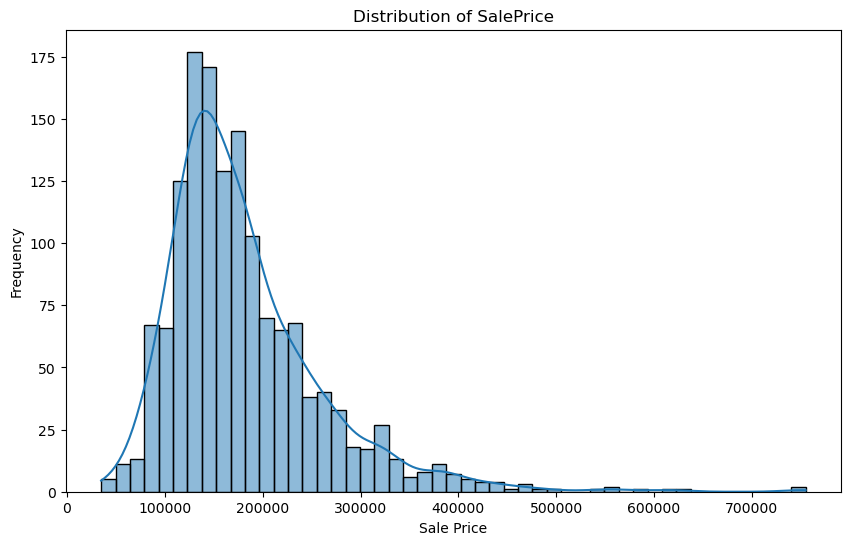

In [85]:
plt.figure(figsize=(10, 6))
sns.histplot(df["SalePrice"], kde=True)
plt.title("Distribution of SalePrice")
plt.xlabel("Sale Price")
plt.ylabel("Frequency")
plt.show()

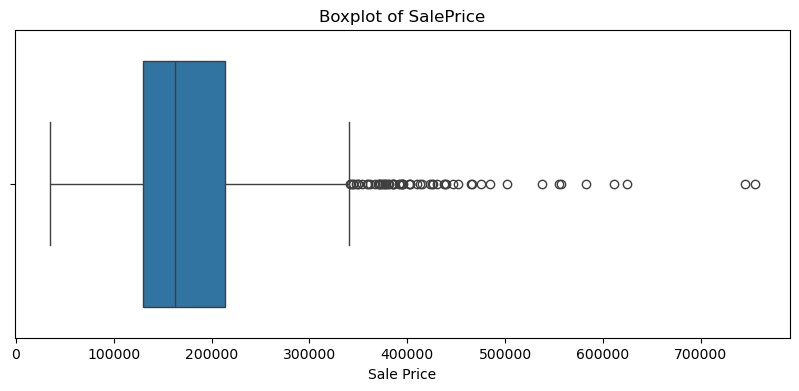

In [86]:
plt.figure(figsize=(10,4))
sns.boxplot(x=df["SalePrice"])
plt.title("Boxplot of SalePrice")
plt.xlabel("Sale Price")
plt.show()

In [87]:
df["SalePrice"].skew()

np.float64(1.8828757597682129)

In [88]:
df["SalePrice"].kurt()

np.float64(6.536281860064529)

In [89]:
numeric_features=df.select_dtypes(include=np.number).columns
numeric_features

Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'MoSold', 'YrSold', 'SalePrice'],
      dtype='object')

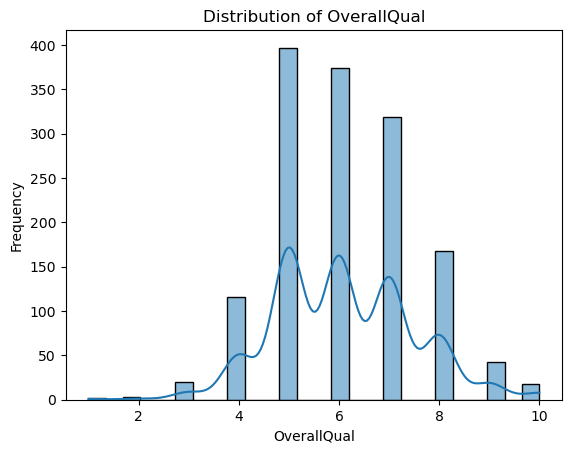

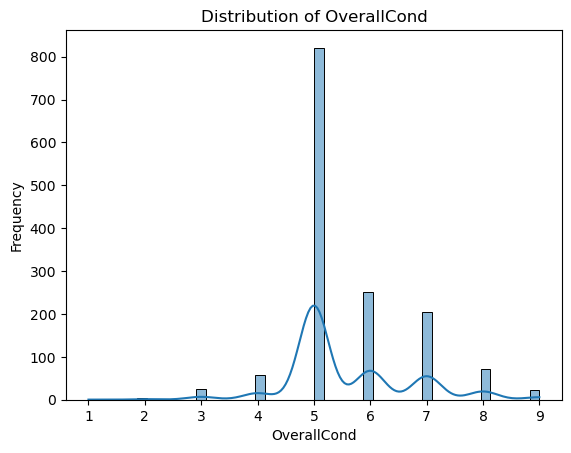

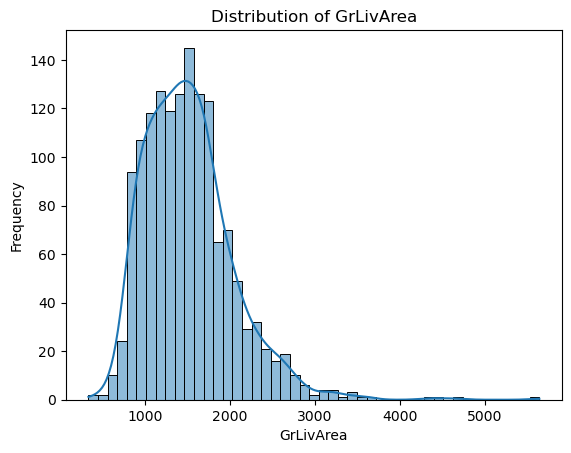

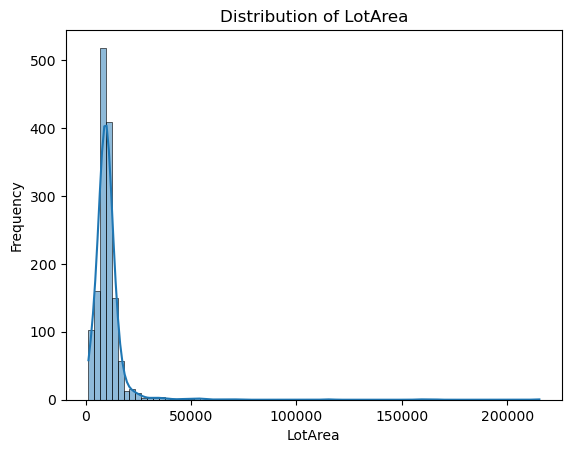

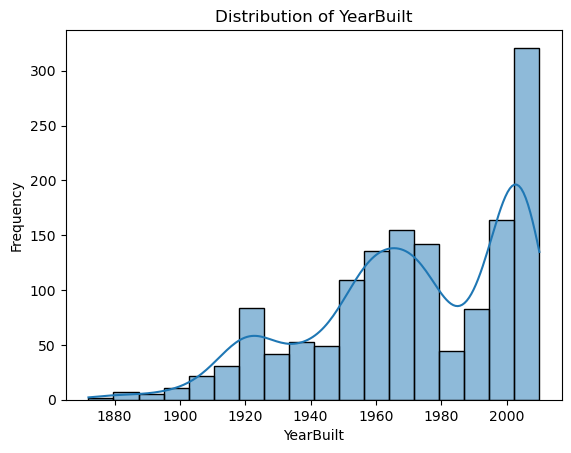

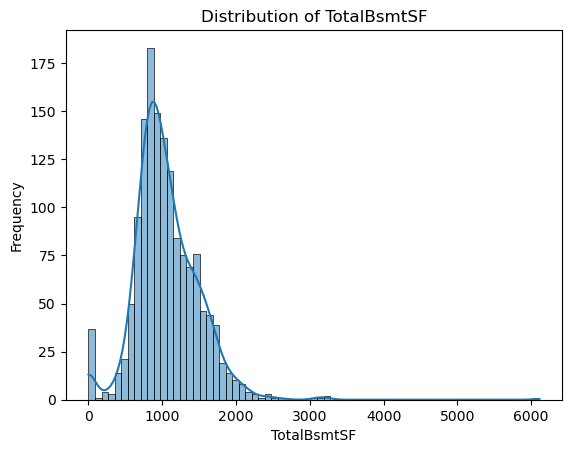

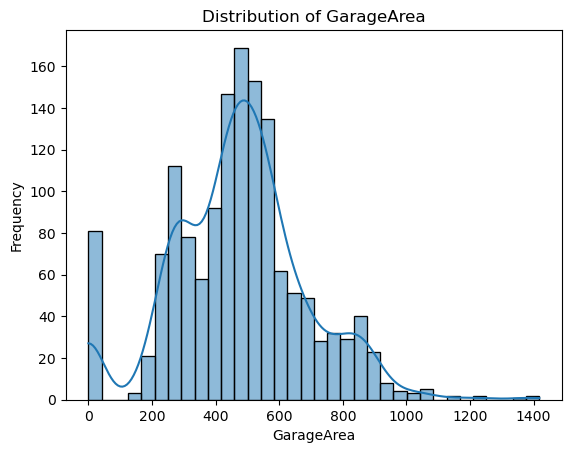

In [90]:
features_to_plot = [
    "OverallQual",
    "OverallCond",
    "GrLivArea",
    "LotArea",
    "YearBuilt",
    "TotalBsmtSF",
    "GarageArea"
]

for feature in features_to_plot:
    sns.histplot(df[feature], kde=True)
    
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    
    plt.show()

In [91]:
correlation_matrix = df.select_dtypes(include=np.number).corr()

In [92]:
correlation_matrix

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
Id,1.000000,0.011156,-0.010601,-0.033226,-0.028365,0.012609,-0.012713,-0.021998,-0.050298,-0.005024,...,-0.029643,-0.000477,0.002889,-0.046635,0.001330,0.057044,-0.006242,0.021172,0.000712,-0.021917
MSSubClass,0.011156,1.000000,-0.386347,-0.139781,0.032628,-0.059316,0.027850,0.040581,0.022936,-0.069836,...,-0.012579,-0.006100,-0.012037,-0.043825,-0.026030,0.008283,-0.007683,-0.013585,-0.021407,-0.084284
LotFrontage,-0.010601,-0.386347,1.000000,0.426095,0.251646,-0.059213,0.123349,0.088866,0.193458,0.233633,...,0.088521,0.151972,0.010700,0.070029,0.041383,0.206167,0.003368,0.011200,0.007450,0.351799
LotArea,-0.033226,-0.139781,0.426095,1.000000,0.105806,-0.005636,0.014228,0.013788,0.104160,0.214103,...,0.171698,0.084774,-0.018340,0.020423,0.043160,0.077672,0.038068,0.001205,-0.014261,0.263843
OverallQual,-0.028365,0.032628,0.251646,0.105806,1.000000,-0.091932,0.572323,0.550684,0.411876,0.239666,...,0.238923,0.308819,-0.113937,0.030371,0.064886,0.065166,-0.031406,0.070815,-0.027347,0.790982
OverallCond,0.012609,-0.059316,-0.059213,-0.005636,-0.091932,1.000000,-0.375983,0.073741,-0.128101,-0.046231,...,-0.003334,-0.032589,0.070356,0.025504,0.054811,-0.001985,0.068777,-0.003511,0.043950,-0.077856
YearBuilt,-0.012713,0.027850,0.123349,0.014228,0.572323,-0.375983,1.000000,0.592855,0.315707,0.249503,...,0.224880,0.188686,-0.387268,0.031355,-0.050364,0.004950,-0.034383,0.012398,-0.013618,0.522897
YearRemodAdd,-0.021998,0.040581,0.088866,0.013788,0.550684,0.073741,0.592855,1.000000,0.179618,0.128451,...,0.205726,0.226298,-0.193919,0.045286,-0.038740,0.005829,-0.010286,0.021490,0.035743,0.507101
MasVnrArea,-0.050298,0.022936,0.193458,0.104160,0.411876,-0.128101,0.315707,0.179618,1.000000,0.264736,...,0.159718,0.125703,-0.110204,0.018796,0.061466,0.011723,-0.029815,-0.005965,-0.008201,0.477493
BsmtFinSF1,-0.005024,-0.069836,0.233633,0.214103,0.239666,-0.046231,0.249503,0.128451,0.264736,1.000000,...,0.204306,0.111761,-0.102303,0.026451,0.062021,0.140491,0.003571,-0.015727,0.014359,0.386420


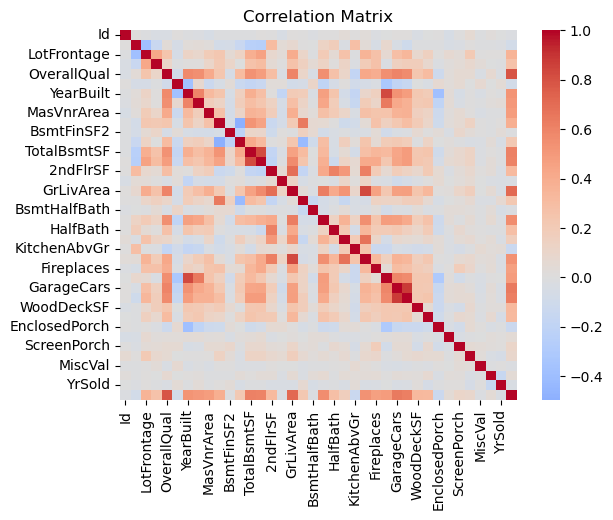

In [93]:
sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")

plt.show()

In [94]:
saleprice_correlation = (
    df.select_dtypes(include=np.number)
      .corr()["SalePrice"]
      .sort_values(ascending=False)
)
saleprice_correlation

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePr

In [95]:
numeric_df = df.select_dtypes(include=np.number).drop("SalePrice", axis=1)

corr_matrix = numeric_df.corr().abs()

high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        if corr_matrix.iloc[i, j] >= 0.80:
            high_corr_pairs.append(
                (
                    corr_matrix.columns[i],
                    corr_matrix.columns[j],
                    corr_matrix.iloc[i, j]
                )
            )

high_corr_pairs

[('YearBuilt', 'GarageYrBlt', np.float64(0.8256674841743408)),
 ('TotalBsmtSF', '1stFlrSF', np.float64(0.8195299750050339)),
 ('GrLivArea', 'TotRmsAbvGrd', np.float64(0.8254893743088425)),
 ('GarageCars', 'GarageArea', np.float64(0.882475414281462))]

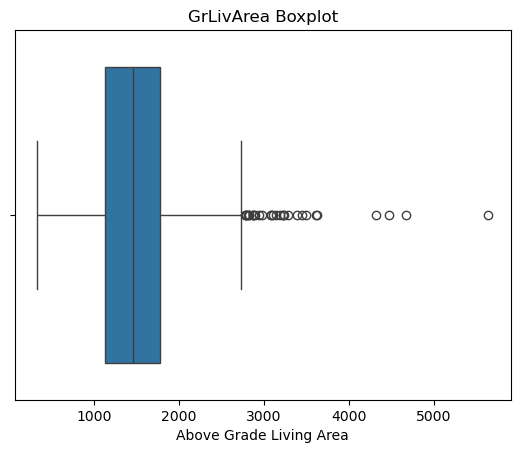

In [96]:
sns.boxplot(x=df["GrLivArea"])

plt.title("GrLivArea Boxplot")
plt.xlabel("Above Grade Living Area")

plt.show()

In [97]:
df_clean = df.copy()

In [98]:
missing_values = df_clean.isnull().sum()
missing_values[missing_values > 0].sort_values(ascending=False)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtFinType1      37
BsmtCond          37
BsmtQual          37
MasVnrArea         8
Electrical         1
dtype: int64

In [99]:
numeric_features = df_clean.select_dtypes(include=np.number).drop("SalePrice").columns
categorical_features = df_clean.select_dtypes(include="object").columns

print("Numerical features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

In [105]:
numeric_missing = df_clean[numeric_features].isnull().sum()

numeric_missing[numeric_missing > 0].sort_values(ascending=False)

LotFrontage    259
GarageYrBlt     81
MasVnrArea       8
dtype: int64

In [106]:
categorical_missing = df_clean[categorical_features].isnull().sum()

categorical_missing[categorical_missing > 0].sort_values(ascending=False)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
GarageType        81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
Electrical         1
dtype: int64

In [113]:
none_columns = [
    "Alley",
    "MasVnrType",
    "BsmtQual",
    "BsmtCond",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2",
    "FireplaceQu",
    "GarageType",
    "GarageFinish",
    "GarageQual",
    "GarageCond",
    "PoolQC",
    "Fence",
    "MiscFeature"
]

for col in none_columns:
    df_clean[col] = df_clean[col].fillna("None")

In [114]:
df_clean["Electrical"] = df_clean["Electrical"].fillna(
    df_clean["Electrical"].mode()[0]
)

In [115]:
zero_columns = [
    "MasVnrArea",
    "GarageYrBlt",
    "BsmtFinSF1",
    "BsmtFinSF2",
    "BsmtUnfSF",
    "TotalBsmtSF",
    "BsmtFullBath",
    "BsmtHalfBath",
    "GarageCars",
    "GarageArea"
]

for col in zero_columns:
    df_clean[col] = df_clean[col].fillna(0)

In [116]:
df_clean["LotFrontage"] = (
    df_clean.groupby("Neighborhood")["LotFrontage"]
    .transform(lambda x: x.fillna(x.median()))
)

df_clean["LotFrontage"] = df_clean["LotFrontage"].fillna(
    df_clean["LotFrontage"].median()
)

In [117]:
remaining_missing = df_clean.isnull().sum()

remaining_missing[remaining_missing > 0]

Series([], dtype: int64)

In [118]:
df_clean.isnull().sum().sum()

np.int64(0)

In [119]:
df_clean.duplicated().sum()

np.int64(0)

In [121]:
outliers = df_clean[
    (df_clean["GrLivArea"] > 4000) &
    (df_clean["SalePrice"] < 300000)
]

df_clean = df_clean.drop(outliers.index).reset_index(drop=True)

In [122]:
print("Shape:", df_clean.shape)
print("Missing values:", df_clean.isnull().sum().sum())
print("Duplicates:", df_clean.duplicated().sum())

Shape: (1458, 81)
Missing values: 0
Duplicates: 0


In [123]:
# Total house area
df_clean["TotalSF"] = (
    df_clean["TotalBsmtSF"] +
    df_clean["1stFlrSF"] +
    df_clean["2ndFlrSF"]
)

In [124]:
# Total bathrooms
df_clean["TotalBathrooms"] = (
    df_clean["FullBath"] +
    0.5 * df_clean["HalfBath"] +
    df_clean["BsmtFullBath"] +
    0.5 * df_clean["BsmtHalfBath"]
)

In [125]:
# House age
df_clean["HouseAge"] = (
    df_clean["YrSold"] -
    df_clean["YearBuilt"]
)

In [126]:
# Years since remodeling
df_clean["RemodAge"] = (
    df_clean["YrSold"] -
    df_clean["YearRemodAdd"]
)

In [127]:
# Garage age
df_clean["GarageAge"] = (
    df_clean["YrSold"] -
    df_clean["GarageYrBlt"]
)

df_clean.loc[
    df_clean["GarageYrBlt"] == 0,
    "GarageAge"
] = 0

In [128]:
# Total porch/deck area
df_clean["TotalPorchSF"] = (
    df_clean["WoodDeckSF"] +
    df_clean["OpenPorchSF"] +
    df_clean["EnclosedPorch"] +
    df_clean["3SsnPorch"] +
    df_clean["ScreenPorch"]
)

In [129]:
# Total finished area
df_clean["TotalFinishedSF"] = (
    df_clean["GrLivArea"] +
    df_clean["BsmtFinSF1"] +
    df_clean["BsmtFinSF2"]
)

In [130]:
new_features = [
    "TotalSF",
    "TotalBathrooms",
    "HouseAge",
    "RemodAge",
    "GarageAge",
    "TotalPorchSF",
    "TotalFinishedSF"
]

df_clean[new_features].head()

,TotalSF,TotalBathrooms,HouseAge,RemodAge,GarageAge,TotalPorchSF,TotalFinishedSF
0,2566,3.5,5,5,5.0,61,2416
1,2524,2.5,31,31,31.0,298,2240
2,2706,3.5,7,6,7.0,42,2272
3,2473,2.0,91,36,8.0,307,1933
4,3343,3.5,8,8,8.0,276,2853


In [131]:
df_clean[
    new_features + ["SalePrice"]
].corr()["SalePrice"].sort_values(ascending=False)

SalePrice          1.000000
TotalSF            0.832877
TotalFinishedSF    0.756612
TotalBathrooms     0.635896
TotalPorchSF       0.392897
GarageAge         -0.390311
RemodAge          -0.509706
HouseAge          -0.524067
Name: SalePrice, dtype: float64

In [132]:
X = df_clean.drop("SalePrice", axis=1)
y = df_clean["SalePrice"]

In [133]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [134]:
numeric_features = X_train.select_dtypes(
    include=np.number
).columns

categorical_features = X_train.select_dtypes(
    include="object"
).columns

In [135]:
print("Numerical features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Numerical features: 44
Categorical features: 43


In [139]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [140]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [143]:
preprocessor = ColumnTransformer([("num", numeric_pipeline, numeric_features),("cat", categorical_pipeline, categorical_features)])

In [144]:
X_train_processed = preprocessor.fit_transform(X_train)

In [145]:
X_test_processed = preprocessor.transform(X_test)

In [146]:
print("Original training shape:", X_train.shape)
print("Processed training shape:", X_train_processed.shape)

print("Original test shape:", X_test.shape)
print("Processed test shape:", X_test_processed.shape)

Original training shape: (1166, 87)
Processed training shape: (1166, 306)
Original test shape: (292, 87)
Processed test shape: (292, 306)


In [151]:
selector = SelectKBest(
    score_func=f_regression,
    k=50
)

X_train_selected = selector.fit_transform(
    X_train_processed,
    y_train
)

X_test_selected = selector.transform(
    X_test_processed
)

print("Before selection:", X_train_processed.shape)
print("After selection:", X_train_selected.shape)

Before selection: (1166, 306)
After selection: (1166, 50)


In [155]:
from sklearn.decomposition import PCA

X_train_dense = X_train_processed.toarray()
X_test_dense = X_test_processed.toarray()

pca = PCA(
    n_components=0.95,
    svd_solver="full"
)

X_train_pca = pca.fit_transform(X_train_dense)
X_test_pca = pca.transform(X_test_dense)

print("Before PCA:", X_train_dense.shape)
print("After PCA:", X_train_pca.shape)
print("PCA components:", pca.n_components_)

Before PCA: (1166, 306)
After PCA: (1166, 74)
PCA components: 74


In [156]:
print(
    "Explained variance:",
    pca.explained_variance_ratio_.sum()
)

Explained variance: 0.9503011920402054


In [165]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    )
}

In [166]:
results = []

for name, model in models.items():

    model.fit(X_train_selected, y_train)

    y_pred = model.predict(X_test_selected)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

In [167]:
results_df = pd.DataFrame(results)

results_df.sort_values("RMSE")

,Model,MAE,RMSE,R2
3,Gradient Boosting,17475.209508,24150.870929,0.894407
1,Ridge,18717.055561,24994.092021,0.886905
2,Random Forest,17484.002614,25776.531891,0.879714
0,Linear Regression,19412.870868,27136.116367,0.866690


In [168]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor

In [169]:
gb_model = GradientBoostingRegressor(
    random_state=42
)

In [170]:
param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [2, 3],
    "min_samples_split": [2, 5]
}

In [171]:
grid_search = GridSearchCV(
    estimator=gb_model,
    param_grid=param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

In [172]:
grid_search.fit(
    X_train_selected,
    y_train
)

,estimator,GradientBoost...ndom_state=42)
,param_grid,"{'learning_rate': [0.05, 0.1], 'max_depth': [2, 3], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'squared_error'


In [173]:
print("Best parameters:")
print(grid_search.best_params_)

Best parameters:
{'learning_rate': 0.05, 'max_depth': 3, 'min_samples_split': 5, 'n_estimators': 200}


In [174]:
print(
    "Best CV RMSE:",
    -grid_search.best_score_
)

Best CV RMSE: 25049.07367754596


In [175]:
best_model = grid_search.best_estimator_

In [176]:
y_pred_final = best_model.predict(X_test_selected)

In [177]:
final_mae = mean_absolute_error(y_test, y_pred_final)

final_rmse = mean_squared_error(
    y_test,
    y_pred_final
) ** 0.5

final_r2 = r2_score(
    y_test,
    y_pred_final
)

In [178]:
print("Final MAE:", final_mae)
print("Final RMSE:", final_rmse)
print("Final R²:", final_r2)

Final MAE: 17247.855635757198
Final RMSE: 23999.66121388763
Final R²: 0.8957255307859797


In [179]:
comparison = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²"],
    "Before Tuning": [
        17475.209508,
        24150.870929,
        0.894407
    ],
    "After Tuning": [
        final_mae,
        final_rmse,
        final_r2
    ]
})

comparison

,Metric,Before Tuning,After Tuning
0,MAE,17475.209508,17247.855636
1,RMSE,24150.870929,23999.661214
2,R²,0.894407,0.895726


In [180]:
final_model = best_model

,Metric,Before Tuning,After Tuning
0,MAE,17475.209508,17247.855636
1,RMSE,24150.870929,23999.661214
2,R²,0.894407,0.895726


In [181]:
import joblib

joblib.dump(preprocessor, "preprocessor.pkl")
joblib.dump(selector, "selector.pkl")
joblib.dump(best_model, "house_price_model.pkl")

['house_price_model.pkl']

In [182]:
preprocessor_loaded = joblib.load("preprocessor.pkl")
selector_loaded = joblib.load("selector.pkl")
model_loaded = joblib.load("house_price_model.pkl")

In [183]:
sample = X_test.iloc[[0]]

In [184]:
sample_processed = preprocessor_loaded.transform(sample)

In [185]:
sample_selected = selector_loaded.transform(sample_processed)

In [186]:
prediction = model_loaded.predict(sample_selected)

print("Predicted House Price:", prediction[0])

Predicted House Price: 215709.21859632284


In [187]:
print(list(X_train.columns))

['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'PoolQC'

In [188]:
import json

sample = X_test.iloc[0].to_dict()

print(json.dumps(sample, indent=4, default=str))

{
    "Id": 1323,
    "MSSubClass": 60,
    "MSZoning": "RL",
    "LotFrontage": 107.0,
    "LotArea": 10186,
    "Street": "Pave",
    "Alley": "None",
    "LotShape": "IR1",
    "LandContour": "Lvl",
    "Utilities": "AllPub",
    "LotConfig": "Inside",
    "LandSlope": "Gtl",
    "Neighborhood": "NoRidge",
    "Condition1": "Norm",
    "Condition2": "Norm",
    "BldgType": "1Fam",
    "HouseStyle": "2Story",
    "OverallQual": 7,
    "OverallCond": 5,
    "YearBuilt": 1992,
    "YearRemodAdd": 1992,
    "RoofStyle": "Gable",
    "RoofMatl": "CompShg",
    "Exterior1st": "HdBoard",
    "Exterior2nd": "HdBoard",
    "MasVnrType": "None",
    "MasVnrArea": 0.0,
    "ExterQual": "Gd",
    "ExterCond": "TA",
    "Foundation": "PConc",
    "BsmtQual": "Gd",
    "BsmtCond": "TA",
    "BsmtExposure": "No",
    "BsmtFinType1": "GLQ",
    "BsmtFinSF1": 674,
    "BsmtFinType2": "Unf",
    "BsmtFinSF2": 0,
    "BsmtUnfSF": 76,
    "TotalBsmtSF": 750,
    "Heating": "GasA",
    "HeatingQC": "Ex"

In [189]:
import joblib

joblib.dump(
    list(X_train.columns),
    "feature_columns.pkl"
)

['feature_columns.pkl']

In [190]:
import json

sample = X_test.iloc[0].copy()

# Remove the 7 engineered features
engineered_features = [
    "TotalSF",
    "TotalBathrooms",
    "HouseAge",
    "RemodAge",
    "GarageAge",
    "TotalPorchSF",
    "TotalFinishedSF"
]

sample = sample.drop(engineered_features)

print(json.dumps(sample.to_dict(), indent=2, default=str))

{
  "Id": 1323,
  "MSSubClass": 60,
  "MSZoning": "RL",
  "LotFrontage": 107.0,
  "LotArea": 10186,
  "Street": "Pave",
  "Alley": "None",
  "LotShape": "IR1",
  "LandContour": "Lvl",
  "Utilities": "AllPub",
  "LotConfig": "Inside",
  "LandSlope": "Gtl",
  "Neighborhood": "NoRidge",
  "Condition1": "Norm",
  "Condition2": "Norm",
  "BldgType": "1Fam",
  "HouseStyle": "2Story",
  "OverallQual": 7,
  "OverallCond": 5,
  "YearBuilt": 1992,
  "YearRemodAdd": 1992,
  "RoofStyle": "Gable",
  "RoofMatl": "CompShg",
  "Exterior1st": "HdBoard",
  "Exterior2nd": "HdBoard",
  "MasVnrType": "None",
  "MasVnrArea": 0.0,
  "ExterQual": "Gd",
  "ExterCond": "TA",
  "Foundation": "PConc",
  "BsmtQual": "Gd",
  "BsmtCond": "TA",
  "BsmtExposure": "No",
  "BsmtFinType1": "GLQ",
  "BsmtFinSF1": 674,
  "BsmtFinType2": "Unf",
  "BsmtFinSF2": 0,
  "BsmtUnfSF": 76,
  "TotalBsmtSF": 750,
  "Heating": "GasA",
  "HeatingQC": "Ex",
  "CentralAir": "Y",
  "Electrical": "SBrkr",
  "1stFlrSF": 1061,
  "2ndFlrSF": 